# Clinical Trial Benchmarking Analysis

This notebook analyzes a raw clinical trial dataset (`raw_trials.csv`) exported from ClinicalTrials.gov.

It performs four steps:
1. Load the raw CSV file
2. Clean the data (fix types, handle missing values, remove duplicates)
3. Calculate benchmarking metrics: phase distribution, top sponsors, median enrollment by phase, and trial duration by phase
4. Save each result as its own CSV file and visualize the two most important ones

No prior setup is needed besides having `raw_trials.csv` in the same folder as this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Show plots inline in the notebook
%matplotlib inline

INPUT_FILE = "raw_trials.csv"
OUTPUT_DIR = "results"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load the raw data

In [2]:
df = pd.read_csv(INPUT_FILE)

print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()

Rows: 2000
Columns: ['nct_id', 'brief_title', 'sponsor_name', 'phase', 'overall_status', 'start_date', 'completion_date', 'enrollment_count', 'interventions']


,nct_id,brief_title,sponsor_name,phase,overall_status,start_date,completion_date,enrollment_count,interventions
0,NCT03816774,Effect of Adding Simethicone to Split-dose Pol...,"Portuguese Oncology Institute, Coimbra",NaN,COMPLETED,2019-06-15,2022-09-17,412.0,PEG split-dose and simethicone
1,NCT04169074,Immune Modulation by Abemaciclib in Head and N...,University of Arizona,PHASE2,TERMINATED,2021-07-07,2025-01-13,7.0,Abemaciclib
2,NCT03983174,Drainage Seton With Flap Versus EAS Preserving...,Mansoura University,NaN,COMPLETED,2017-01-01,2019-04-30,100.0,Drainage seton with flap; EAS sparing seton
3,NCT00898118,Studying Blood Samples in Young Patients With ...,European Working Group of MDS in Childhood,NaN,UNKNOWN,2007-04,NaN,125.0,polymerase chain reaction; flow cytometry; lab...
4,NCT01414790,The Use of Human Acellular Dermal Matrix to Im...,West China Hospital,PHASE3,COMPLETED,2004-01,2011-01,70.0,ADM


## 2. Clean the data

- `enrollment_count` is converted to a proper numeric column.
- `start_date` / `completion_date` are converted to real dates. Some dates in this
  dataset only have a year and month (e.g. `2007-04`), so we treat those as the
  1st of that month.
- Missing `phase` values (including the text `"NA"`) are labeled `"N/A"`.
- Missing `sponsor_name` values are labeled `"Unknown"`.
- Duplicate `nct_id` rows are dropped.

In [3]:
def parse_date(value):
    """Converts a date string to a real date, handling year-month-only values."""
    if pd.isna(value):
        return pd.NaT
    value = str(value).strip()
    if len(value) == 7:          # e.g. "2007-04" -> "2007-04-01"
        value = value + "-01"
    return pd.to_datetime(value, errors="coerce")


clean_df = df.copy()

clean_df["enrollment_count"] = pd.to_numeric(clean_df["enrollment_count"], errors="coerce")

clean_df["start_date"] = clean_df["start_date"].apply(parse_date)
clean_df["completion_date"] = clean_df["completion_date"].apply(parse_date)

clean_df["phase"] = clean_df["phase"].fillna("N/A")
clean_df["phase"] = clean_df["phase"].replace({"NA": "N/A"})

clean_df["sponsor_name"] = clean_df["sponsor_name"].fillna("Unknown")

clean_df = clean_df.drop_duplicates(subset=["nct_id"])

print("Rows after cleaning:", len(clean_df))
clean_df.head()

Rows after cleaning: 2000


,nct_id,brief_title,sponsor_name,phase,overall_status,start_date,completion_date,enrollment_count,interventions
0,NCT03816774,Effect of Adding Simethicone to Split-dose Pol...,"Portuguese Oncology Institute, Coimbra",N/A,COMPLETED,2019-06-15,2022-09-17,412.0,PEG split-dose and simethicone
1,NCT04169074,Immune Modulation by Abemaciclib in Head and N...,University of Arizona,PHASE2,TERMINATED,2021-07-07,2025-01-13,7.0,Abemaciclib
2,NCT03983174,Drainage Seton With Flap Versus EAS Preserving...,Mansoura University,N/A,COMPLETED,2017-01-01,2019-04-30,100.0,Drainage seton with flap; EAS sparing seton
3,NCT00898118,Studying Blood Samples in Young Patients With ...,European Working Group of MDS in Childhood,N/A,UNKNOWN,2007-04-01,NaT,125.0,polymerase chain reaction; flow cytometry; lab...
4,NCT01414790,The Use of Human Acellular Dermal Matrix to Im...,West China Hospital,PHASE3,COMPLETED,2004-01-01,2011-01-01,70.0,ADM


## 3. Phase distribution

In [4]:
phase_distribution = clean_df["phase"].value_counts().reset_index()
phase_distribution.columns = ["phase", "trial_count"]

total = phase_distribution["trial_count"].sum()
phase_distribution["percentage"] = (phase_distribution["trial_count"] / total * 100).round(2)

phase_distribution

,phase,trial_count,percentage
0,N/A,819,40.95
1,PHASE2,551,27.55
2,PHASE1,400,20.00
3,PHASE3,161,8.05
4,PHASE4,35,1.75
5,EARLY_PHASE1,34,1.70


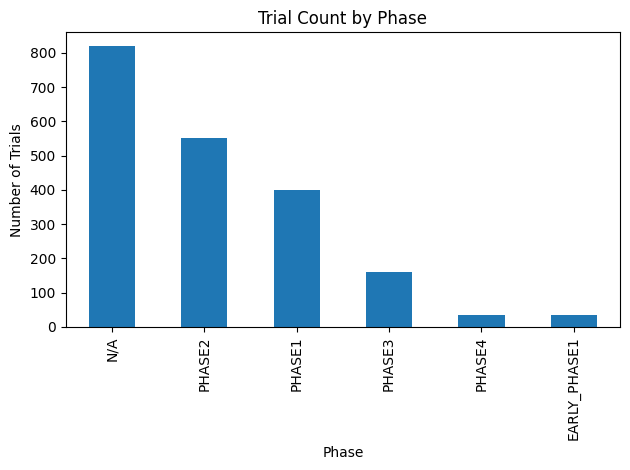

In [5]:
phase_distribution.plot(
    kind="bar", x="phase", y="trial_count", legend=False,
    title="Trial Count by Phase", xlabel="Phase", ylabel="Number of Trials"
)
plt.tight_layout()
plt.show()

## 4. Top 10 sponsors

In [6]:
top_sponsors = clean_df["sponsor_name"].value_counts().head(10).reset_index()
top_sponsors.columns = ["sponsor_name", "trial_count"]

top_sponsors

,sponsor_name,trial_count
0,National Cancer Institute (NCI),57
1,M.D. Anderson Cancer Center,40
2,Memorial Sloan Kettering Cancer Center,27
3,Sun Yat-sen University,24
4,Novartis Pharmaceuticals,23
5,Mayo Clinic,22
6,Fudan University,17
7,Hoffmann-La Roche,17
8,Massachusetts General Hospital,17
9,AstraZeneca,16


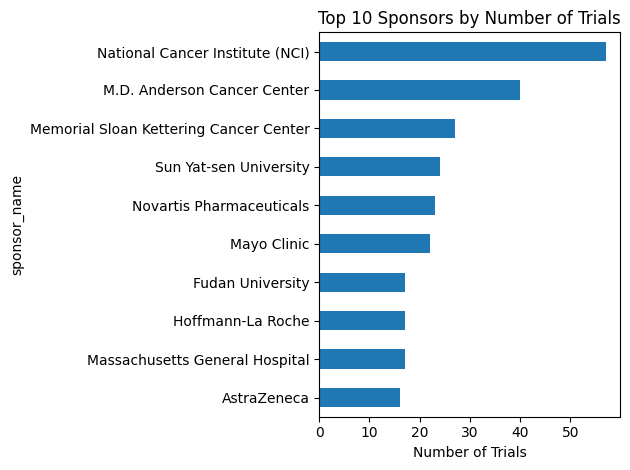

In [7]:
top_sponsors.plot(
    kind="barh", x="sponsor_name", y="trial_count", legend=False,
    title="Top 10 Sponsors by Number of Trials", xlabel="Number of Trials"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Median enrollment by phase

In [8]:
median_enrollment = clean_df.groupby("phase")["enrollment_count"].median().reset_index()
median_enrollment.columns = ["phase", "median_enrollment"]
median_enrollment = median_enrollment.sort_values("median_enrollment", ascending=False)

median_enrollment

,phase,median_enrollment
4,PHASE3,302.0
5,PHASE4,102.0
1,N/A,100.0
3,PHASE2,47.0
2,PHASE1,32.0
0,EARLY_PHASE1,27.5


## 6. Trial duration summary by phase

In [9]:
duration_df = clean_df.copy()
duration_df["duration_days"] = (duration_df["completion_date"] - duration_df["start_date"]).dt.days

duration_df = duration_df[duration_df["duration_days"].notna()]
duration_df = duration_df[duration_df["duration_days"] >= 0]

trial_duration_summary = duration_df.groupby("phase")["duration_days"].agg(
    ["mean", "median", "min", "max", "count"]
).reset_index()

trial_duration_summary.columns = [
    "phase", "avg_duration_days", "median_duration_days",
    "min_duration_days", "max_duration_days", "trial_count"
]
trial_duration_summary["avg_duration_days"] = trial_duration_summary["avg_duration_days"].round(1)

trial_duration_summary

,phase,avg_duration_days,median_duration_days,min_duration_days,max_duration_days,trial_count
0,EARLY_PHASE1,1447.1,1189.0,128.0,6399.0,33
1,N/A,1460.8,1034.5,0.0,14610.0,792
2,PHASE1,1538.4,1259.0,0.0,6022.0,385
3,PHASE2,1759.1,1461.0,0.0,7190.0,528
4,PHASE3,2056.6,1903.5,126.0,5849.0,150
5,PHASE4,1203.8,1171.5,120.0,2892.0,34


## 7. Save results

In [10]:
phase_distribution.to_csv(f"{OUTPUT_DIR}/phase_distribution.csv", index=False)
top_sponsors.to_csv(f"{OUTPUT_DIR}/top_sponsors.csv", index=False)
median_enrollment.to_csv(f"{OUTPUT_DIR}/median_enrollment_by_phase.csv", index=False)
trial_duration_summary.to_csv(f"{OUTPUT_DIR}/trial_duration_summary.csv", index=False)

print("All result files saved in the '" + OUTPUT_DIR + "' folder:")
for name in ["phase_distribution.csv", "top_sponsors.csv",
             "median_enrollment_by_phase.csv", "trial_duration_summary.csv"]:
    print(" -", name)

All result files saved in the 'results' folder:
 - phase_distribution.csv
 - top_sponsors.csv
 - median_enrollment_by_phase.csv
 - trial_duration_summary.csv
